C:\Users\emili\AppData\Local\Temp\ipykernel_21028\3124963828.py:160: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, len(recortes_resized))#, figsize=(15, 5))


No se encontró el archivo pkl, se utilizarán los pesos iniciales.
Dimensión de la matriz de pesos: (57, 784)
Salida final: [ 0.          0.          0.          0.          0.          0.
  0.          0.         65.01252109  0.          0.          0.
 66.59191711  0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  9.8199312   0.          0.          0.         65.89882935  0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.        ]

Letra: M

Salida final: [40.81027917  0.          0.          0.          0.          0.
  0.          0.         40.01842677  0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.      

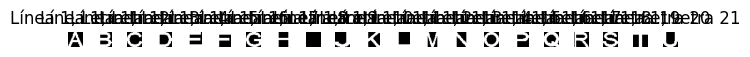

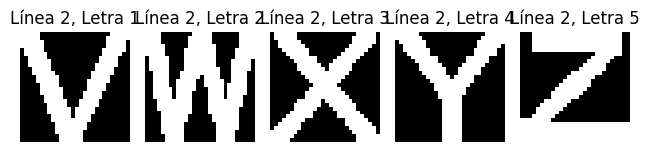

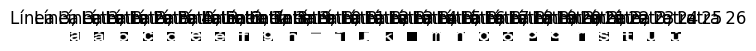

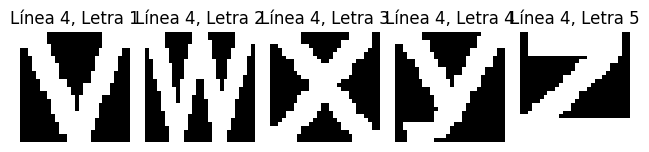

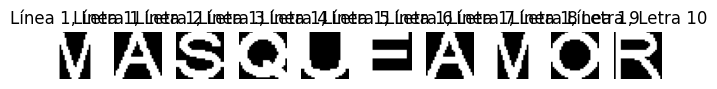

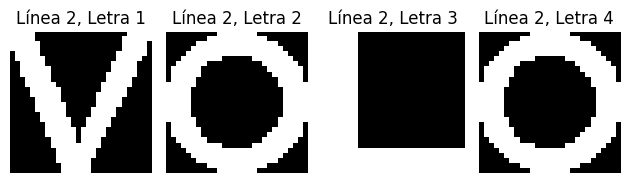

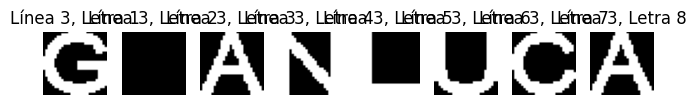

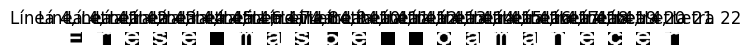

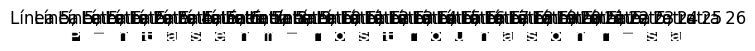

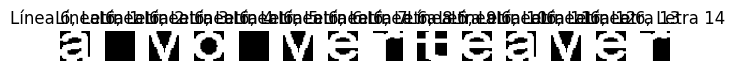

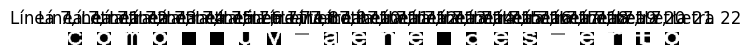

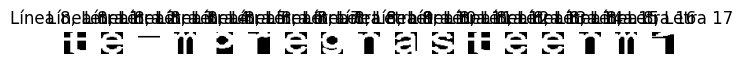

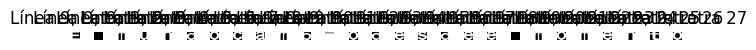

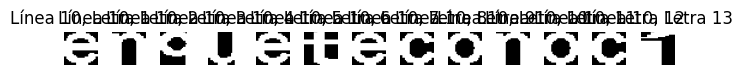

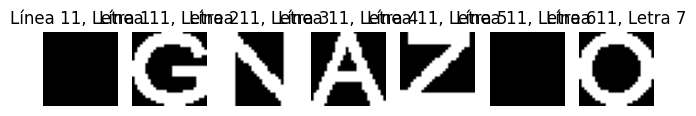

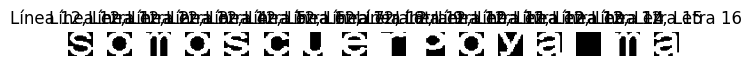

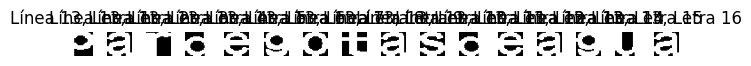

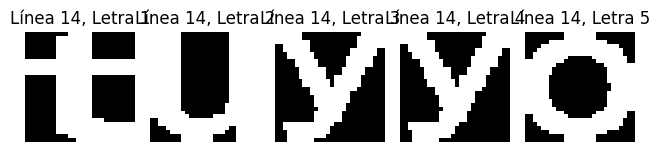

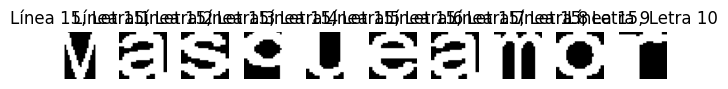

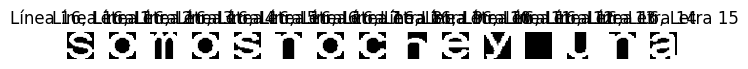

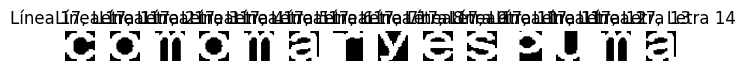

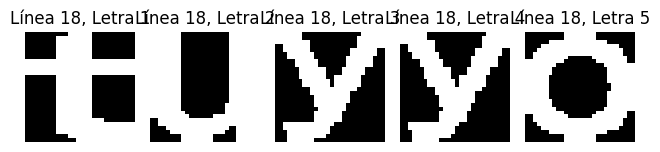

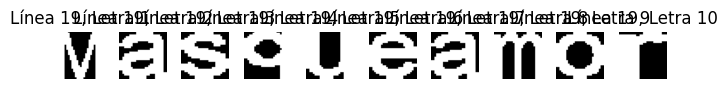

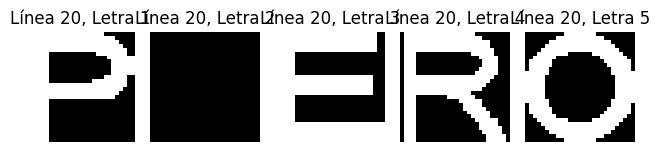

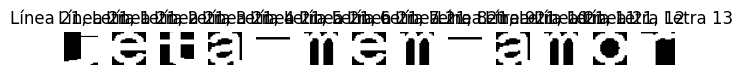

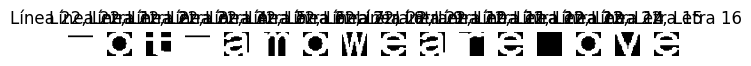

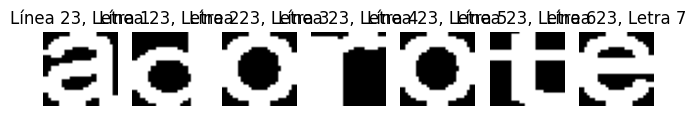

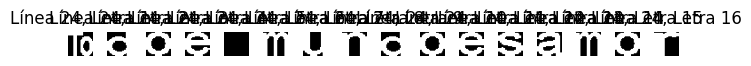

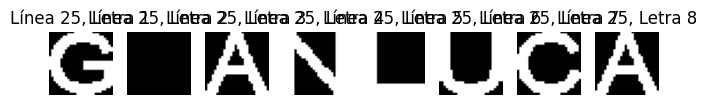

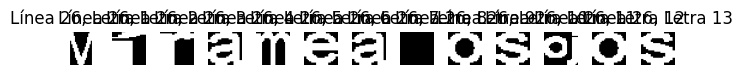

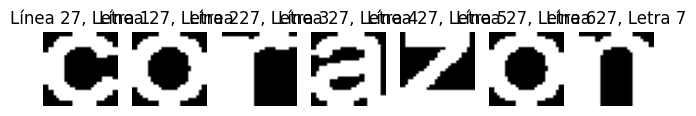

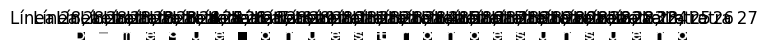

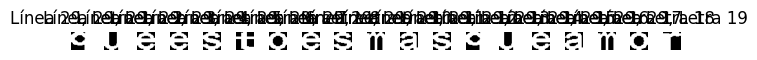

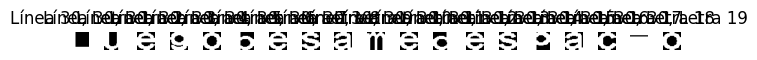

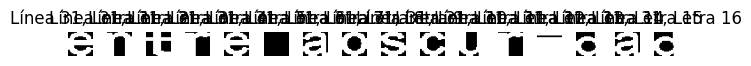

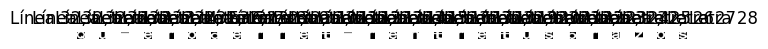

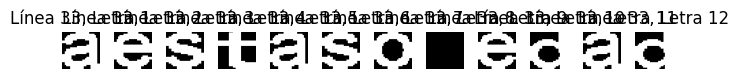

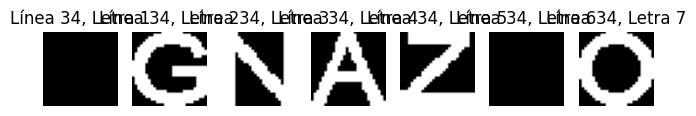

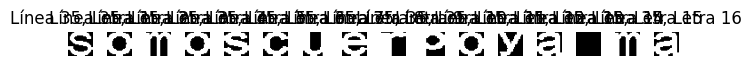

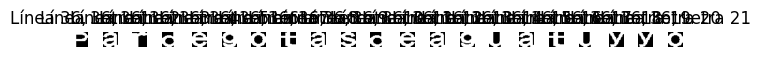

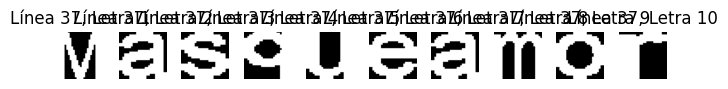

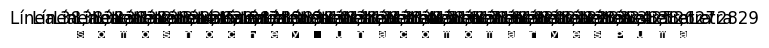

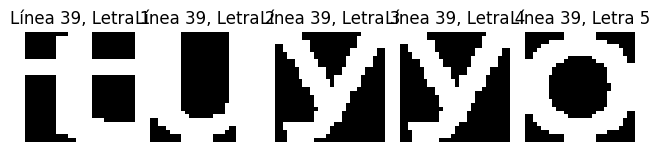

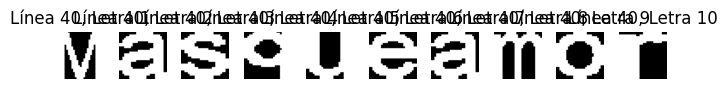

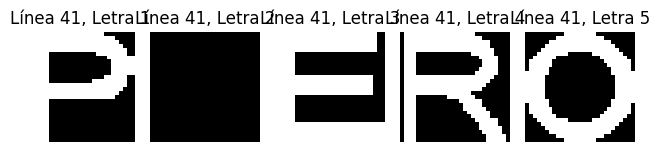

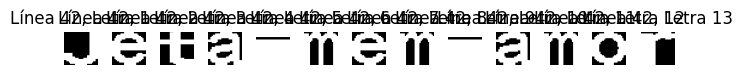

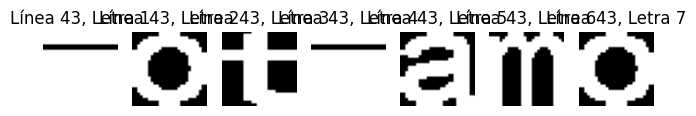

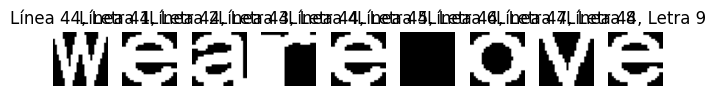

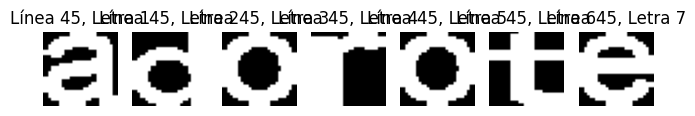

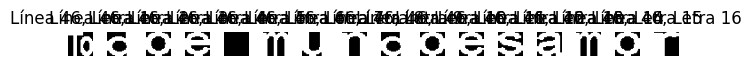

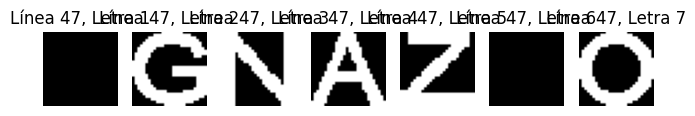

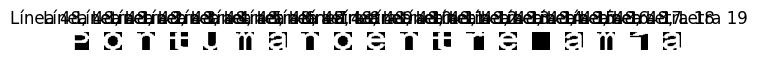

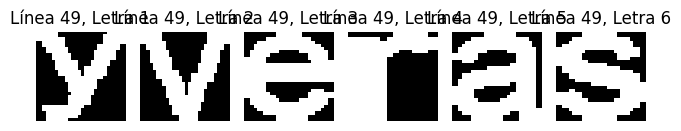

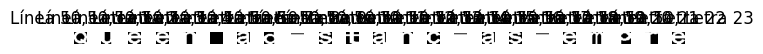

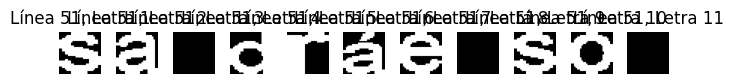

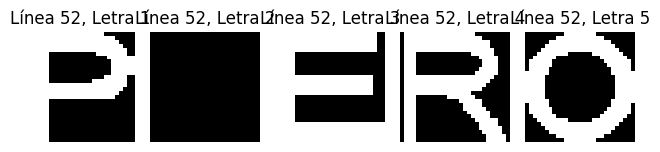

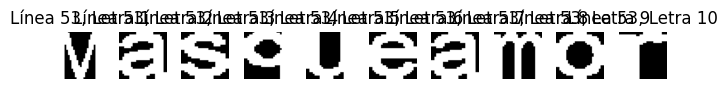

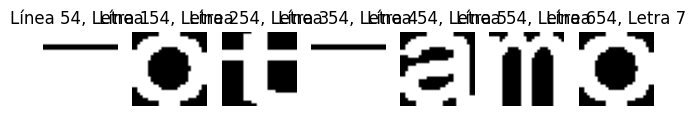

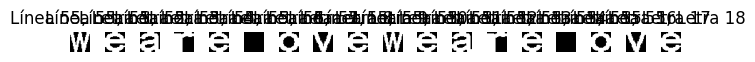

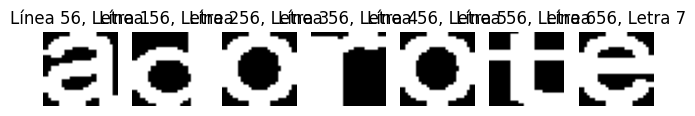

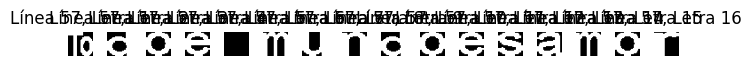

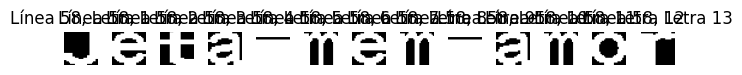

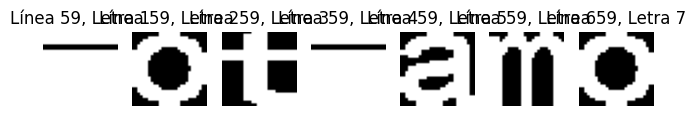

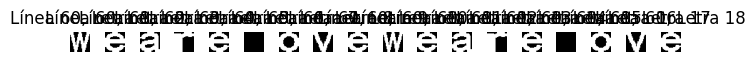

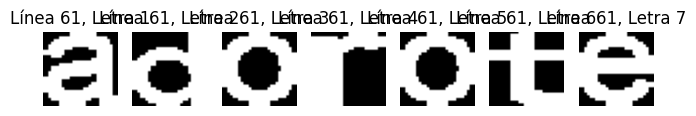

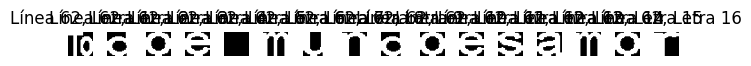

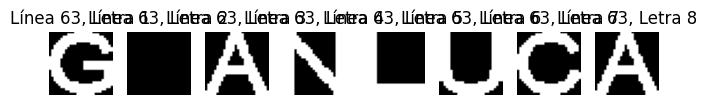

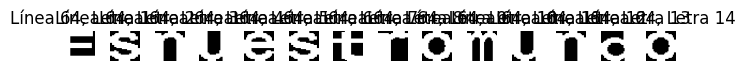

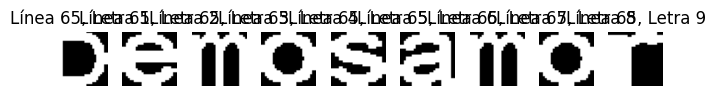

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import disk, dilation,closing,opening
from skimage import io, color
from skimage.transform import resize
from gtts import gTTS
import os
from PIL import Image
import pickle

#Lectura de las imágenes a utilizar
# imagendb=io.imread(r'D:\Upiita\6to\IA\Fotos\Abecedario.bmp')
#imagendb=Image.open(r'D:\Upiita\6to\IA\Fotos\Abecedario.bmp').convert('RGB')
imagenp=io.imread(r"D:\Upiita\6to\IA\Fotos\poema_arial2.bmp")
imagendb=io.imread(r"D:\Upiita\6to\IA\Fotos\abecedario_4.bmp")
#imagendb=io.imread(r'C:\Users\lrl13\Downloads\abcedario.jpeg')
imagendb=np.array(imagendb)
#imagenp=io.imread(r'D:\Upiita\6to\IA\Fotos\poema_t.bmp')
#Etiquetas para asignar letras a cada neurona
# abecedario = (
#     'A','B', 'C', 'D','E',  'F','G',  'H', 'I', 'J', 'K', 'L', 'M', 'N',
#     'Ñ' , 'O','P', 'Q', 'R','S','T','U','V','W','X','Y', 'Z',
#     'a','b','c','d','e','f','g','h','i','j','k','l', 'm','n','ñ',
#     'o','p','q','r','s','t','u','v','w','x','y','z',
#     'á', 'é', 'í', 'ó','ú',
#     'Á', 'É', 'Í','Ó','Ú'
# )

# abecedario = (#sin ñÑ
#     'A','B', 'C', 'D','E',  'F','G',  'H', 'I', 'J', 'K', 'L', 'M', 'N',
#     'O','P', 'Q', 'R','S','T','U','V','W','X','Y', 'Z',
#     'a','b','c','d','e','f','g','h','i','j','k','l', 'm','n',
#     'o','p','q','r','s','t','u','v','w','x','y','z',
#     'á', 'é', 'í', 'ó','ú',
#     'Á', 'É', 'Í','Ó','Ú'
# )
abecedario = (#sin ñÑ
    'A','B', 'C', 'D','E',  'F','G',  'H', 'I', 'J', 'K', 'L', 'M', 'N',
    'O','P', 'Q', 'R','S','T','U','V','W','X','Y', 'Z',
    'a','á','b','c','d','e','é','f','g','h','i','í','j','k','l', 'm','n',
    'o','ó','p','q','r','s','t','u','ú','v','w','x','y','z'
)

#Función para el procesamiento de imágenes digital dependiendo de la situación
def gbf(imagen,im):
    if im == 'w':
        gris = color.rgb2gray(imagen)
        binario = (gris < 0.5)
        # estructura = 
        # binario=opening(binario,disk(1))
        #binario = dilation(binario,disk(0.6)) 
        #binario = closing(binario,disk(1)) 
    elif im == 'pv':
        gris = color.rgb2gray(imagen)
        binario = (gris < 0.5)
    elif im == 'p':
        binario=imagen
        #binario = dilation(binario,disk(0.7)) 
        #binario = closing(binario,disk(1)) 
    return binario
#Función para hacer el corte horizontal de líneas de texto
def recorta_lineas(imagen):
    puntosY = []
    imagenes = []
    coords=[]
    filai=0
    while np.any(imagen == 1):
        for fila in range(filai, imagen.shape[0]):
            if np.any(imagen[fila, :] == 1):
                puntosY.insert(0, fila)
                break
        for fila in range(puntosY[0], imagen.shape[0]):
            if np.all(imagen[fila, :] == 0):
                puntosY.append(fila)
                break
        if len(puntosY) == 2:
            recorte = imagen[puntosY[0]-4:puntosY[1]+2, :]
            coords.append((puntosY[0] - 4, puntosY[1] + 2))
            imagen = imagen[puntosY[1]:imagen.shape[0], :]
            imagenes.append(recorte)
            puntosY = []
    return None, imagen, imagenes,coords

#Función para realizar la extracción de letras (recortes) de cada línea de texto
def extrae_letras(recorte):
    puntosX = []
    puntosY = []
    recortes = []
    recorte_letra = None
    coordenadas=[]

 
    while np.any(recorte == 1):
        if np.any(recorte == 1):
         
            for columna in range(recorte.shape[1]):
                if np.any(recorte[:, columna] == 1):  
                    puntosX.insert(0, columna)
                    break

   
            for columna in range(puntosX[0], recorte.shape[1]):
                if np.all(recorte[:, columna] == 0):#and not (np.any(recorte_letra[columna:recorte_letra.shape[0],:]==1)): 
                    puntosX.append(columna)
                    break


            for fila in range(0, recorte.shape[0]):
                for columna in range(puntosX[0], puntosX[1]):
                    if recorte[fila, columna] == 1: 
                        puntosY.insert(0, fila)
                        break
                if puntosY:
                    break

            recorte_letra = recorte[:, puntosX[0]:puntosX[1]]

            if puntosY:
                for fila in range(puntosY[0], recorte_letra.shape[0]):
                    if np.all(recorte_letra[fila, :] == 0)and not (np.any(recorte_letra[fila:recorte_letra.shape[0],:]==1)):
                        puntosY.append(fila)
                        break

                recorte_letra = recorte[puntosY[0]-1:puntosY[1]+1, puntosX[0]-1:puntosX[1]+1]
                recortes.append(recorte_letra)
                coordenadas.append((puntosX[0]-1, puntosY[0]-1, puntosX[1]+1, puntosY[1]+1))

            recorte = recorte[:, puntosX[1]:recorte.shape[1]]
            puntosX = []
            puntosY = []

        else:
            break

 
    if recorte_letra is None:
        recorte_letra = np.zeros((1, 1))  

    return recortes, recorte_letra, coordenadas

#Función para Guardar un vector de entrada con las líneas recortadas
def guarda_letras(lineas, coordenadas_lineas, wp):
    vectores=[]
    coordenadas_letras = []

    for idx, (linea, (y0, y1)) in enumerate(zip(lineas, coordenadas_lineas)):
        recortes, _,coords = extrae_letras(np.array(linea))
        coordenadas_letras.extend(coords)

        if wp=='w':
            recortes_resized = [resize(letra, (28, 28), anti_aliasing=True) for letra in recortes]
        elif wp=='p':
            recortes_resized = [resize(gbf(letra,'p'), (28, 28), anti_aliasing=True) for letra in recortes]
        recortes.extend(recortes_resized)

        for recorte in recortes_resized:
            recorte[recorte > 0] = 1 
            vectores.append(recorte.flatten())

        fig, axes = plt.subplots(1, len(recortes_resized))#, figsize=(15, 5))
        if len(recortes_resized) == 1:
            axes = [axes]

        for i, recorte_letra in enumerate(recortes_resized):
            axes[i].imshow(recorte_letra, cmap='gray')
            axes[i].axis('off')
            axes[i].set_title(f"Línea {idx + 1}, Letra {i + 1}")

        plt.tight_layout()

    return vectores, coordenadas_letras

def Instar_Compet_T(patrones,W):
    pkl='pesos_bias.pkl'
    if os.path.exists(pkl):
        with open(pkl, 'rb') as f:
            data = pickle.load(f)
            W = data['W']
            bias = data['bias']
        print("Pesos y bias cargados desde el archivo pkl.")
    else:
        print("No se encontró el archivo pkl, se utilizarán los pesos iniciales.")
        bias = np.ones(W.shape[0])

    Salida=[]
    epsilon=0.0153 
    epocas=1
    alpha=0.0001
    
    print(f"Dimensión de la matriz de pesos: {W.shape}")
    R=len(patrones[0])
    b1=R-10
    bias=np.ones(W.shape[0])
    epsilon=0.0153
    iteracion=30


    for _ in range(epocas):
        for i in range(patrones.shape[0]):
            a1 = np.dot(W, patrones[i, :].T) + bias
            ganador = np.argmax(a1)
            for j in range(W.shape[0]):
                if j == ganador:
                    W[j, :] += alpha * (patrones[i, :] - W[j, :])
            bias[ganador] -= 0.2 * (1 + bias[ganador])
    
        with open(pkl, 'wb') as f:
            pickle.dump({'W': W, 'bias': bias}, f)
            # print("Pesos y bias guardados en el archivo pkl.")

    for idx , patron in enumerate(patrones): #patron: 2x1
        a1=np.dot(W,patron)+b1
        a2 = a1.copy()
        for _ in range(iteracion): 
            new_a2 = np.zeros_like(a2)
            for i in range(len(a2)):
                ini = epsilon * (np.sum(a2) - a2[i])
                new_a2[i] = max(0, a2[i] - ini)
            a2 = new_a2
        winner_ind=np.argmax(a2)
    # print(f"Patron de entrada {idx+1} : {patron}")
    # print(f"Neurona ganadora {winner_ind+1} : {patron}")
        print(f"Salida final: {a2}\n")
        print(f"Letra: {abecedario[winner_ind]}\n")
        Salida.append(abecedario[winner_ind])
    return Salida

#Función para concatenar las letras según la distancia que mantienen entre sí
def concatena_letras(letras, coordenadas, umbral):
    texto = ""

    for i in range(len(letras)):
        texto += letras[i]

        if i < len(letras) - 1:
            x1 = coordenadas[i][2] 
            x0_sig = coordenadas[i + 1][0] 
            
            if (x1-x0_sig) <= umbral:
                texto += " "
    for i in range(len(letras) - 1):
        x1 = coordenadas[i][2] 
        x0_sig = coordenadas[i + 1][0]  
        print(f"Distancia entre '{letras[i]}' y '{letras[i + 1]}': {x1-x0_sig}")

    return texto
#Función para convertir el Texto a Voz y Recitarlo
def recitar(text, output_file='output.mp3'):
    tts = gTTS(text=text, lang='es')
    tts.save(output_file)
    os.system(f"start {output_file}") 

abc =  imagendb
abc = gbf(abc,'w')*1
_,_, s,coordlw= recorta_lineas(abc)
vectoresw,coordsw=guarda_letras(s,coordlw,'w')

poema =  imagenp
poema = gbf(poema,'pv')*1
_,_, s ,coordlp = recorta_lineas(poema)
vectoresp,coordsp=guarda_letras(s,coordlp,'p')

patrones=np.array(vectoresp,dtype=np.float64)
W=np.array(vectoresw,dtype=np.float64)

Salida=Instar_Compet_T(patrones,W)

texto=concatena_letras(Salida,coordsp,umbral=9)
print(f"Texto concatenado: {texto}")

recitar(texto)
# plt.show()